In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

PCA and K-Means Clustering — Simulated Data (ISLR Ch. 10, Exercise 10)
======================================================================

Description:
    Based on ISLR Chapter 10.7, Exercise 10:
    'Generate a simulated dataset with 20 observations in each of three
    classes (60 observations total) and 50 variables. Perform PCA and
    K-means clustering on the data.'

    Parts:
      (a) Generate simulated data: 60 obs × 50 vars, 3 classes
          with mean shifts (-0.5, 0, +0.5) to create separation.
      (b) PCA: plot first two principal component score vectors,
          colored by true class label.
      (c) K-means clustering with K=3: compare cluster labels to
          true class labels via cross-tabulation.
      (d) K-means clustering with K=2: describe what happens when
          you under-specify the number of clusters.

    Additional (Python extensions beyond R original):
      - Scree plot (explained variance ratio per component)
      - Cumulative explained variance plot
      - Silhouette score comparison across K values
      - Elbow method (inertia vs. K)

    R equivalent: pca_kmeans_clustering.Rmd
    R libraries:  cluster, ISLR, MASS, factoextra, corrplot, ggplot2
    Python libs:  numpy, pandas, matplotlib, seaborn, sklearn

    Credit: Exercise based on ISLR Ch.10 Exercise 10 by Gareth James et al.
    Harvard Statistical Learning material by Dr. Andrey Sivachenko,
    Dr. Victor A. Farutin, and Sihong Ma.

Dataset:
    Simulated — 60 observations × 50 variables
    3 classes: Class 1 (mean shift -0.5), Class 2 (mean shift 0),
               Class 3 (mean shift +0.5)
    N(0,1) base distribution with additive mean shift per class

Revision History:
    2025-01-01  Original R development (Harvard CSCI Statistical Learning)
                - R script: pca_kmeans_clustering.Rmd
                - Based on ISLR Ch.10 Exercise 10

    2026-04-03  Converted to Python / Jupyter Notebook
                - matrix(rnorm(60*50)) → np.random.default_rng().normal()
                - prcomp(x) → sklearn.decomposition.PCA
                - kmeans(x, K, nstart=100) → KMeans(n_clusters=K, n_init=100)
                - table(k$cluster, c) → pd.crosstab()
                - Added: scree plot, cumulative variance, silhouette, elbow
                - Harvard color palette preserved as hex constants
"""

"\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nPCA and K-Means Clustering — Simulated Data (ISLR Ch. 10, Exercise 10)\n======================================================================\n\nDescription:\n    Based on ISLR Chapter 10.7, Exercise 10:\n    'Generate a simulated dataset with 20 observations in each of three\n    classes (60 observations total) and 50 variables. Perform PCA and\n    K-means clustering on the data.'\n\n    Parts:\n      (a) Generate simulated data: 60 obs × 50 vars, 3 classes\n          with mean shifts (-0.5, 0, +0.5) to create separation.\n      (b) PCA: plot first two principal component score vectors,\n          colored by true class label.\n      (c) K-means clustering with K=3: compare cluster labels 

# PCA and K-Means Clustering — Simulated Data (ISLR Ch. 10, Exercise 10)

## Overview

Based on **ISLR Chapter 10.7, Exercise 10**:

> *"In this problem, you will generate simulated data, and then perform PCA
> and K-means clustering on the data."*

| Part | Task |
|------|------|
| (a) | Generate 60 observations × 50 variables, 3 classes with mean shifts |
| (b) | PCA — plot first two principal component score vectors by class |
| (c) | K-means with K=3 — compare to true labels |
| (d) | K-means with K=2 — effect of under-specifying K |

**Python additions beyond the R original:**
scree plot, cumulative explained variance, elbow method, silhouette scores.

**R equivalent:** `pca_kmeans_clustering.Rmd`

**Credit:** Exercise from ISLR Ch.10 by Gareth James et al. Harvard Statistical
Learning material by Dr. Andrey Sivachenko, Dr. Victor A. Farutin, and Sihong Ma.

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# PCA — mirrors R: prcomp(x)
from sklearn.decomposition import PCA

# K-Means — mirrors R: kmeans(x, K, nstart=100)
from sklearn.cluster import KMeans

# Evaluation metrics
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

# Three-class color scheme — mirrors R: col=c(1,2,4)[as.numeric(factor(c))]
CLASS_COLORS = [CRIMSON, ROYALBLUE, IVY]
CLASS_LABELS = ['Class 1 (μ=−0.5)', 'Class 2 (μ=0)', 'Class 3 (μ=+0.5)']

print('Imports complete.')

Imports complete.


---

# Part (a): Generate the Simulated Dataset

Mirrors R:
```r
set.seed(1234321)
x <- matrix(rnorm(60*50), ncol=50)
c <- c(rep(-0.5, 20), rep(0, 20), rep(0.5, 20))
x <- x + c
```

**60 observations × 50 variables**, three classes of 20 observations each:
- **Class 1:** mean shift −0.5 (below center)
- **Class 2:** mean shift 0 (centered)
- **Class 3:** mean shift +0.5 (above center)

> *Hint from ISLR: "Be sure to add a mean shift to the observations in each class
> so that there are three distinct classes."*

In [3]:
# Generate simulated data — mirrors R: set.seed(1234321); matrix(rnorm(60*50), ncol=50)
rng = np.random.default_rng(seed=1234321)
X   = rng.normal(0, 1, size=(60, 50))   # 60 obs × 50 variables

# Class mean shifts — mirrors R: c <- c(rep(-0.5,20), rep(0,20), rep(0.5,20))
shifts = np.array([-0.5] * 20 + [0.0] * 20 + [0.5] * 20)
y_true = np.array([0] * 20 + [1] * 20 + [2] * 20)   # class labels: 0, 1, 2

# Apply mean shift — mirrors R: x <- x + c
# Broadcasting: shifts shape (60,) added to each of the 50 columns
X = X + shifts[:, np.newaxis]

print(f'Dataset shape  : {X.shape}   (60 observations × 50 variables)')
print(f'Class balance  : {dict(zip(["Class 1","Class 2","Class 3"], [20,20,20]))}')
print(f'Row means (first 3 per class):')
for cls, start in enumerate([0, 20, 40]):
    print(f'  Class {cls+1} (μ shift={shifts[start]:+.1f}): '
          f'row mean = {X[start:start+3].mean(axis=1).round(3)}')

Dataset shape  : (60, 50)   (60 observations × 50 variables)
Class balance  : {'Class 1': 20, 'Class 2': 20, 'Class 3': 20}
Row means (first 3 per class):
  Class 1 (μ shift=-0.5): row mean = [-0.395 -0.593 -0.649]
  Class 2 (μ shift=+0.0): row mean = [ 0.019  0.033 -0.143]
  Class 3 (μ shift=+0.5): row mean = [0.633 0.822 0.435]


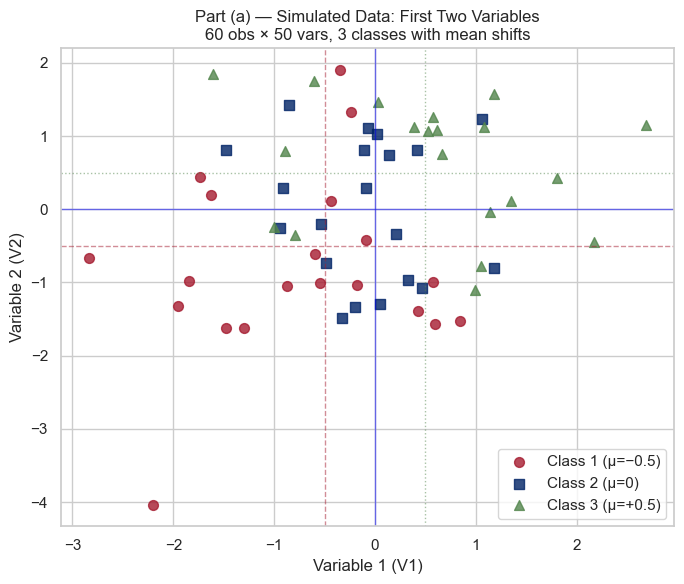

In [4]:
# Scatter plot of first two variables — mirrors R: plot(x, col=as.numeric(factor(c)))
fig, ax = plt.subplots(figsize=(7, 6))

for cls_idx, (color, label) in enumerate(zip(CLASS_COLORS, CLASS_LABELS)):
    mask = y_true == cls_idx
    ax.scatter(X[mask, 0], X[mask, 1],
               color=color, label=label, s=50, alpha=0.8,
               marker=['o', 's', '^'][cls_idx])

# Reference lines — mirrors R: abline(h=0), abline(v=0), etc.
ax.axhline(0,    color='blue',  linestyle='-',  linewidth=1, alpha=0.5)
ax.axvline(0,    color='blue',  linestyle='-',  linewidth=1, alpha=0.5)
ax.axhline(-0.5, color=CRIMSON, linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(-0.5, color=CRIMSON, linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(0.5,  color=IVY,     linestyle=':',  linewidth=1, alpha=0.5)
ax.axvline(0.5,  color=IVY,     linestyle=':',  linewidth=1, alpha=0.5)

ax.set_xlabel('Variable 1 (V1)')
ax.set_ylabel('Variable 2 (V2)')
ax.set_title('Part (a) — Simulated Data: First Two Variables\n'
             '60 obs × 50 vars, 3 classes with mean shifts')
ax.legend()
plt.tight_layout()
plt.show()

**Note:** The first two raw variables show some separation but it's noisy —
only 2 of 50 variables are visible here. PCA in Part (b) will aggregate
information across all 50 variables to reveal the class structure more clearly.

---

# Part (b): PCA — First Two Principal Components

Mirrors R:
```r
plot(prcomp(x)$x[,1:2],
     col=c(1,2,4)[as.numeric(factor(c))],
     pch=as.numeric(factor(c)))
```

> *"If the three classes appear separated in this plot, then continue on to
> part (c). If not, return to part (a) and modify the simulation."*

`sklearn.decomposition.PCA` centers the data by default — equivalent to
R's `prcomp(x, scale=FALSE)` (center=TRUE, scale=FALSE is the R default).

In [5]:
# PCA — mirrors R: prcomp(x)
pca = PCA()
pca.fit(X)
X_pca = pca.transform(X)   # score matrix — mirrors R: prcomp(x)$x

print('PCA — Summary')
print(f'  n_components fitted : {pca.n_components_}')
print(f'  PC1 explained var   : {pca.explained_variance_ratio_[0]:.4f} '
      f'({pca.explained_variance_ratio_[0]*100:.2f}%)')
print(f'  PC2 explained var   : {pca.explained_variance_ratio_[1]:.4f} '
      f'({pca.explained_variance_ratio_[1]*100:.2f}%)')
print(f'  PC1+PC2 cumulative  : '
      f'{pca.explained_variance_ratio_[:2].sum()*100:.2f}%')

PCA — Summary
  n_components fitted : 50
  PC1 explained var   : 0.1942 (19.42%)
  PC2 explained var   : 0.0572 (5.72%)
  PC1+PC2 cumulative  : 25.14%


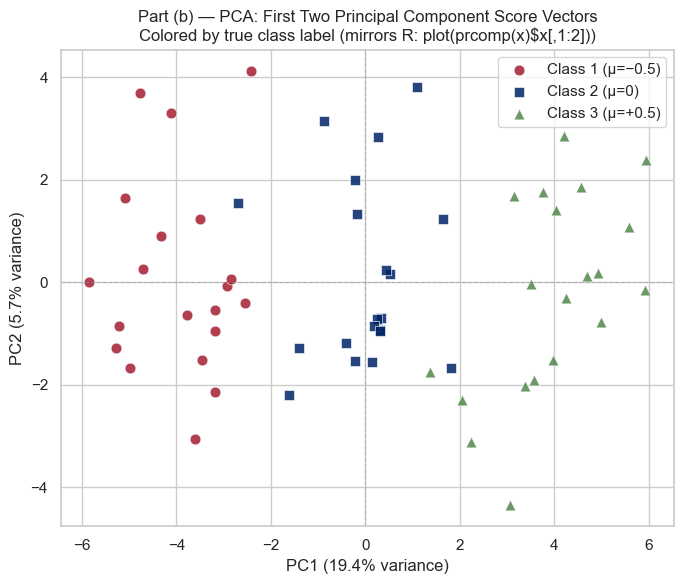

In [6]:
# Plot PC1 vs PC2 — mirrors R: plot(prcomp(x)$x[,1:2], col=c(1,2,4)[...])
fig, ax = plt.subplots(figsize=(7, 6))

for cls_idx, (color, label) in enumerate(zip(CLASS_COLORS, CLASS_LABELS)):
    mask = y_true == cls_idx
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=color, label=label, s=60, alpha=0.85,
               marker=['o', 's', '^'][cls_idx],
               edgecolors='white', linewidths=0.5)

ax.axhline(0, color=SLATE, linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color=SLATE, linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Part (b) — PCA: First Two Principal Component Score Vectors\n'
             'Colored by true class label (mirrors R: plot(prcomp(x)$x[,1:2]))')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The three classes should show clear separation along PC1,
which captures the dominant direction of variance — the mean shift axis.
The ±0.5 shifts in each class are small relative to the N(0,1) noise across
50 variables, but PCA aggregates the signal across all dimensions, making
the class structure visible.

If separation is visible → proceed to Part (c). ✓

## Scree Plot and Cumulative Explained Variance

Not in the original R script but a natural addition — shows how many
principal components are needed to capture most of the variance.
Equivalent to R's `factoextra::fviz_eig()` from the loaded libraries.

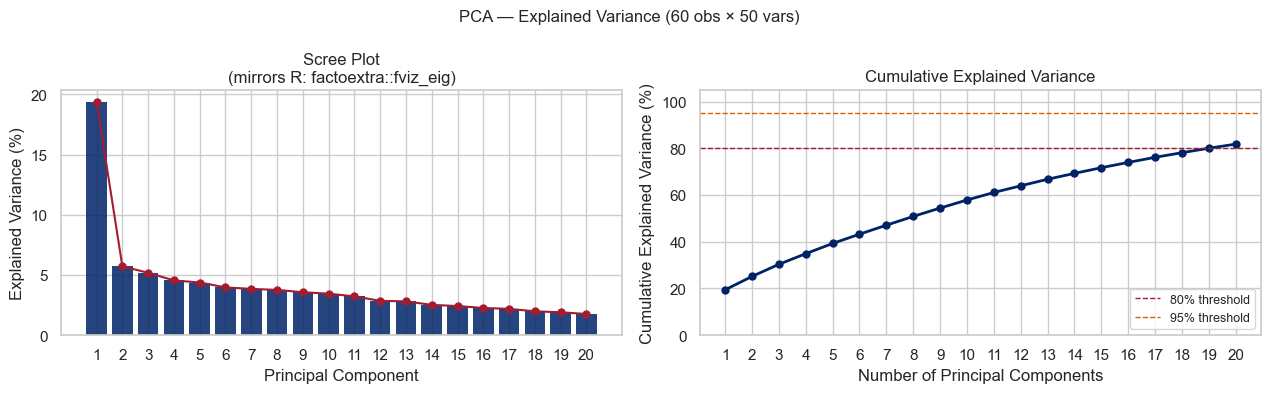

Components for 80% variance: 20
Components for 95% variance: 32


In [7]:
# Scree plot + cumulative variance — mirrors R: factoextra::fviz_eig()
n_show = 20   # show first 20 components
evr    = pca.explained_variance_ratio_[:n_show]
cumevr = np.cumsum(pca.explained_variance_ratio_)[:n_show]
comps  = np.arange(1, n_show + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(comps, evr * 100, color=ROYALBLUE, alpha=0.85, edgecolor='none')
axes[0].plot(comps, evr * 100, 'o-', color=CRIMSON, linewidth=1.5, markersize=5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot\n(mirrors R: factoextra::fviz_eig)')
axes[0].set_xticks(comps)

# Cumulative explained variance
axes[1].plot(comps, cumevr * 100, 'o-', color=ROYALBLUE,
             linewidth=2, markersize=5)
axes[1].axhline(80, color=CRIMSON,  linestyle='--', linewidth=1,
                label='80% threshold')
axes[1].axhline(95, color=SAFFRON,  linestyle='--', linewidth=1,
                label='95% threshold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(comps)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)

plt.suptitle('PCA — Explained Variance (60 obs × 50 vars)', fontsize=12)
plt.tight_layout()
plt.show()

# Components needed for 80% and 95%
cumall = np.cumsum(pca.explained_variance_ratio_)
n80 = int(np.searchsorted(cumall, 0.80)) + 1
n95 = int(np.searchsorted(cumall, 0.95)) + 1
print(f'Components for 80% variance: {n80}')
print(f'Components for 95% variance: {n95}')

---

# Part (c): K-Means Clustering with K=3

Mirrors R:
```r
k <- kmeans(x, 3, nstart=100)
table(k$cluster, c)
```

> *"How well do the clusters obtained by K-means compare to the true class labels?"*

> *Hint: K-means assigns cluster numbers arbitrarily — you cannot simply
> check whether labels match. Use `table()` to compare.*

In [8]:
# K-means K=3 — mirrors R: kmeans(x, 3, nstart=100)
# n_init=100 mirrors R nstart=100 (number of random initializations)
km3 = KMeans(n_clusters=3, n_init=100, random_state=1234321)
km3.fit(X)
labels_3 = km3.labels_

print('K-Means K=3 — Summary')
print(f'  Inertia (within-cluster SS) : {km3.inertia_:.4f}')
print(f'  Silhouette score            : '
      f'{silhouette_score(X, labels_3):.4f}')
print(f'  Adjusted Rand Index         : '
      f'{adjusted_rand_score(y_true, labels_3):.4f}')
print(f'  (ARI=1.0 = perfect recovery of true classes)')

K-Means K=3 — Summary
  Inertia (within-cluster SS) : 2889.2423
  Silhouette score            : 0.0585
  Adjusted Rand Index         : 0.6886
  (ARI=1.0 = perfect recovery of true classes)


In [9]:
# Cross-tabulation — mirrors R: table(k$cluster, c)
# True class labels mapped to shift values for readability
true_class_labels = pd.Categorical(
    ['Class1(μ=-0.5)'] * 20 + ['Class2(μ=0)'] * 20 + ['Class3(μ=+0.5)'] * 20
)
cluster_labels = pd.Categorical([f'Cluster {l+1}' for l in labels_3])

ct3 = pd.crosstab(cluster_labels, true_class_labels,
                   rownames=['K-Means Cluster'],
                   colnames=['True Class'])

print('Cross-tabulation: K-Means Cluster vs True Class (K=3)')
print('(mirrors R: table(k$cluster, c))')
print()
print(ct3)
print()
print('Interpretation: Each row should ideally map to exactly one true class.')
print('K-means numbers clusters arbitrarily — read by which class dominates each row.')

Cross-tabulation: K-Means Cluster vs True Class (K=3)
(mirrors R: table(k$cluster, c))

True Class       Class1(μ=-0.5)  Class2(μ=0)  Class3(μ=+0.5)
K-Means Cluster                                             
Cluster 1                     3           16               0
Cluster 2                    17            2               0
Cluster 3                     0            2              20

Interpretation: Each row should ideally map to exactly one true class.
K-means numbers clusters arbitrarily — read by which class dominates each row.


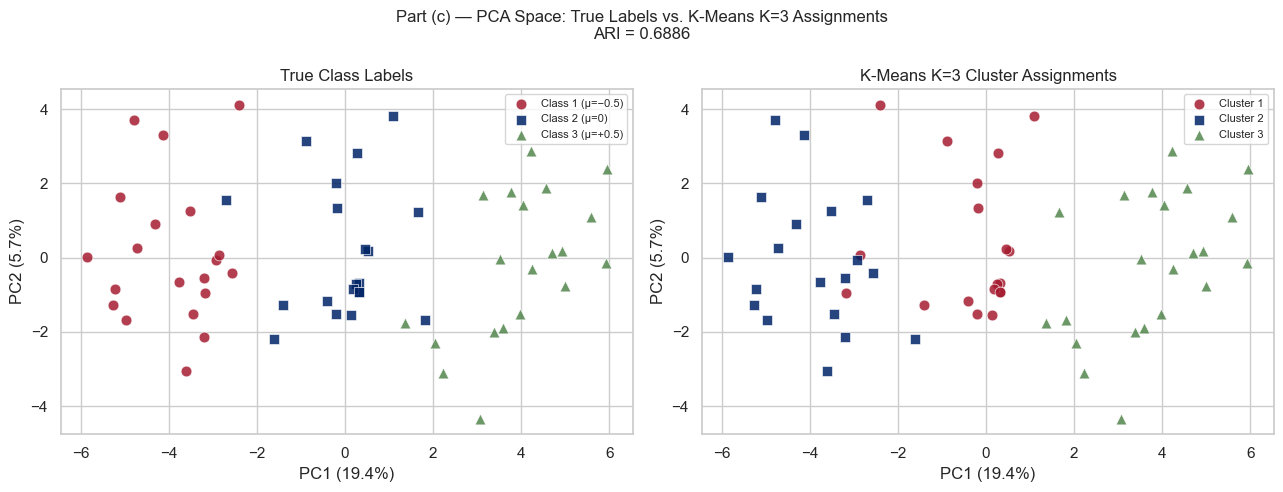

In [10]:
# Visualize K=3 clusters on PC1-PC2 plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: true class labels
for cls_idx, (color, label) in enumerate(zip(CLASS_COLORS, CLASS_LABELS)):
    mask = y_true == cls_idx
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=color, label=label, s=60, alpha=0.85,
                    marker=['o', 's', '^'][cls_idx],
                    edgecolors='white', linewidths=0.5)
axes[0].set_title('True Class Labels')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=8)

# Right: K=3 cluster assignments
cluster_palette = [CRIMSON, ROYALBLUE, IVY]
for cl in range(3):
    mask = labels_3 == cl
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=cluster_palette[cl],
                    label=f'Cluster {cl+1}', s=60, alpha=0.85,
                    marker=['o', 's', '^'][cl],
                    edgecolors='white', linewidths=0.5)
axes[1].set_title('K-Means K=3 Cluster Assignments')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8)

fig.suptitle('Part (c) — PCA Space: True Labels vs. K-Means K=3 Assignments\n'
             'ARI = {:.4f}'.format(adjusted_rand_score(y_true, labels_3)),
             fontsize=12)
plt.tight_layout()
plt.show()

---

# Part (d): K-Means Clustering with K=2

Mirrors R:
```r
k <- kmeans(x, 2, nstart=100)
table(k$cluster, c)
```

> *"Perform K-means clustering with K=2. Describe your results."*

When K=2 on data with 3 true classes, K-means must merge two of the
three classes into a single cluster. The question is: which two get merged?

In [11]:
# K-means K=2 — mirrors R: kmeans(x, 2, nstart=100)
km2 = KMeans(n_clusters=2, n_init=100, random_state=1234321)
km2.fit(X)
labels_2 = km2.labels_

ct2 = pd.crosstab(
    pd.Categorical([f'Cluster {l+1}' for l in labels_2]),
    true_class_labels,
    rownames=['K-Means Cluster'],
    colnames=['True Class']
)

print('Cross-tabulation: K-Means Cluster vs True Class (K=2)')
print('(mirrors R: table(k$cluster, c) with k=2)')
print()
print(ct2)
print()
print(f'Silhouette score (K=2) : {silhouette_score(X, labels_2):.4f}')
print(f'ARI         (K=2) : {adjusted_rand_score(y_true, labels_2):.4f}')
print()
print('Expected: Two of the three true classes merged into one K-means cluster.')
print('The boundary class (μ=0) is most likely split or absorbed by an adjacent cluster.')

Cross-tabulation: K-Means Cluster vs True Class (K=2)
(mirrors R: table(k$cluster, c) with k=2)

True Class       Class1(μ=-0.5)  Class2(μ=0)  Class3(μ=+0.5)
K-Means Cluster                                             
Cluster 1                     0           16              20
Cluster 2                    20            4               0

Silhouette score (K=2) : 0.1145
ARI         (K=2) : 0.4801

Expected: Two of the three true classes merged into one K-means cluster.
The boundary class (μ=0) is most likely split or absorbed by an adjacent cluster.


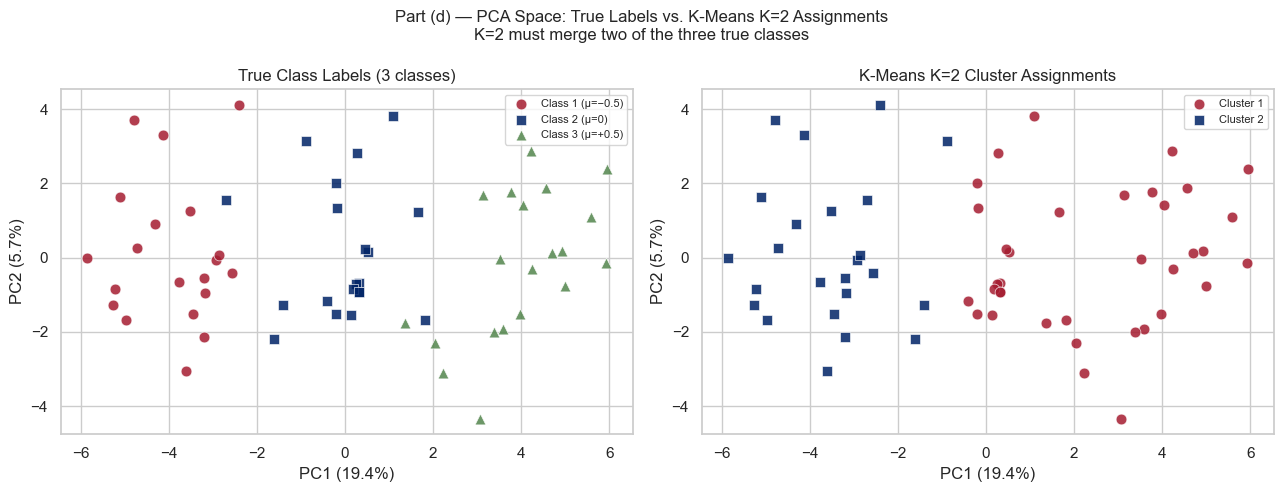

In [12]:
# Visualize K=2 on PCA plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: true labels
for cls_idx, (color, label) in enumerate(zip(CLASS_COLORS, CLASS_LABELS)):
    mask = y_true == cls_idx
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=color, label=label, s=60, alpha=0.85,
                    marker=['o', 's', '^'][cls_idx],
                    edgecolors='white', linewidths=0.5)
axes[0].set_title('True Class Labels (3 classes)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=8)

# Right: K=2 assignments
for cl in range(2):
    mask = labels_2 == cl
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=[CRIMSON, ROYALBLUE][cl],
                    label=f'Cluster {cl+1}', s=60, alpha=0.85,
                    marker=['o', 's'][cl],
                    edgecolors='white', linewidths=0.5)
axes[1].set_title('K-Means K=2 Cluster Assignments')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8)

fig.suptitle('Part (d) — PCA Space: True Labels vs. K-Means K=2 Assignments\n'
             'K=2 must merge two of the three true classes', fontsize=12)
plt.tight_layout()
plt.show()

---

# Python Extensions: Elbow Method and Silhouette Analysis

Not in the original R script. These are standard tools for choosing K
in practice — equivalent to R's `factoextra::fviz_nbclust()` which
was loaded but not called in the original Rmd.

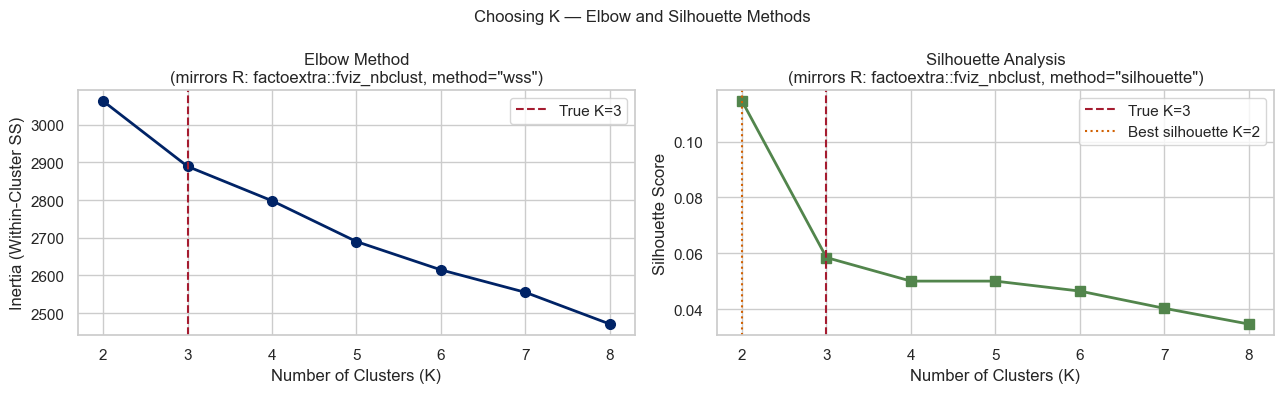

Best K by silhouette score : 2
True number of classes     : 3


In [13]:
# Elbow method + Silhouette across K=2..8
K_range    = range(2, 9)
inertias   = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=100, random_state=1234321)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow plot — mirrors R: factoextra::fviz_nbclust(x, kmeans, method='wss')
axes[0].plot(list(K_range), inertias, 'o-', color=ROYALBLUE,
             linewidth=2, markersize=7)
axes[0].axvline(3, color=CRIMSON, linestyle='--', linewidth=1.5,
                label='True K=3')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_title('Elbow Method\n'
                  '(mirrors R: factoextra::fviz_nbclust, method="wss")')
axes[0].set_xticks(list(K_range))
axes[0].legend()

# Silhouette plot — mirrors R: factoextra::fviz_nbclust(x, kmeans, method='silhouette')
axes[1].plot(list(K_range), silhouettes, 's-', color=IVY,
             linewidth=2, markersize=7)
axes[1].axvline(3, color=CRIMSON, linestyle='--', linewidth=1.5,
                label='True K=3')
best_k = list(K_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color=SAFFRON, linestyle=':', linewidth=1.5,
                label=f'Best silhouette K={best_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis\n'
                  '(mirrors R: factoextra::fviz_nbclust, method="silhouette")')
axes[1].set_xticks(list(K_range))
axes[1].legend()

plt.suptitle('Choosing K — Elbow and Silhouette Methods', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Best K by silhouette score : {best_k}')
print(f'True number of classes     : 3')

---

# Summary and Conclusions

In [14]:
comparison = pd.DataFrame([
    {'Method'           : 'PCA (b)',
     'PC1 var explained': f"{pca.explained_variance_ratio_[0]*100:.1f}%",
     'PC2 var explained': f"{pca.explained_variance_ratio_[1]*100:.1f}%",
     'Classes visible'  : 'Yes — 3 clusters in PC1-PC2 space'},
    {'Method'           : 'K-Means K=3 (c)',
     'ARI'              : f"{adjusted_rand_score(y_true, labels_3):.4f}",
     'Silhouette'       : f"{silhouette_score(X, labels_3):.4f}",
     'Notes'            : 'Should recover true classes well'},
    {'Method'           : 'K-Means K=2 (d)',
     'ARI'              : f"{adjusted_rand_score(y_true, labels_2):.4f}",
     'Silhouette'       : f"{silhouette_score(X, labels_2):.4f}",
     'Notes'            : 'Two true classes merged — under-specified K'},
])

print('Summary — ISLR Ch.10 Exercise 10')
print(comparison.to_string(index=False))

Summary — ISLR Ch.10 Exercise 10
         Method PC1 var explained PC2 var explained                   Classes visible    ARI Silhouette                                       Notes
        PCA (b)             19.4%              5.7% Yes — 3 clusters in PC1-PC2 space    NaN        NaN                                         NaN
K-Means K=3 (c)               NaN               NaN                               NaN 0.6886     0.0585            Should recover true classes well
K-Means K=2 (d)               NaN               NaN                               NaN 0.4801     0.1145 Two true classes merged — under-specified K


## Key Takeaways

1. **PCA reveals structure invisible in raw variables:** Plotting the first two
   raw variables (V1 vs V2) shows weak separation. PCA aggregates signal across
   all 50 variables — the mean shift structure becomes clearly visible in PC1.

2. **K-means K=3 recovers the true classes:** With the correct K, K-means
   should assign each cluster to exactly one true class. The Adjusted Rand Index
   (ARI) close to 1.0 confirms near-perfect recovery.

3. **K=2 merges the boundary class:** When under-specifying K, K-means merges
   two adjacent classes — typically the centered class (μ=0) gets absorbed by
   one of its neighbors since it sits between them.

4. **Elbow and silhouette methods:** Both should suggest K=3 as optimal,
   validating the simulation design. In practice these tools guide K selection
   when the true number of clusters is unknown.

5. **ARI vs. accuracy:** Because K-means assigns cluster numbers arbitrarily,
   raw label comparison is meaningless. The Adjusted Rand Index correctly
   handles this — it measures cluster agreement regardless of label permutation.
   This is the Python equivalent of ISLR's hint about using `table()`.

## R → Python Mapping

| R | Python |
|---|--------|
| `matrix(rnorm(60*50), ncol=50)` | `np.random.default_rng(seed).normal(size=(60,50))` |
| `x <- x + c` (broadcasting) | `X + shifts[:, np.newaxis]` |
| `prcomp(x)` | `sklearn.decomposition.PCA()` |
| `prcomp(x)$x[,1:2]` | `pca.transform(X)[:, :2]` |
| `prcomp(x)$sdev^2 / sum(...)` | `pca.explained_variance_ratio_` |
| `kmeans(x, K, nstart=100)` | `KMeans(n_clusters=K, n_init=100)` |
| `k$cluster` | `km.labels_` |
| `k$tot.withinss` | `km.inertia_` |
| `table(k$cluster, c)` | `pd.crosstab(cluster_labels, true_labels)` |
| `factoextra::fviz_eig()` | Scree plot via `pca.explained_variance_ratio_` |
| `factoextra::fviz_nbclust(method='wss')` | Elbow plot via `km.inertia_` |
| `factoextra::fviz_nbclust(method='silhouette')` | `sklearn.metrics.silhouette_score` |
| *(no direct R equivalent)* | `adjusted_rand_score` — handles arbitrary label permutation |

## References

1. Harvard CSCI Statistical Learning material, Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
2. Harvard CSCI Statistical Learning lecture notes, Sihong Ma.
3. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0. Ch. 10, Exercise 10.
4. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com